# Select reports for manual labelling

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import datetime as dt
from src.text_processing_functions import *
from src.LLM_functions import *
import copy as cp
import geopandas as gpd
import matplotlib.pyplot as plt

from src.data import *
from src.labelling_helpers import *
from src.geocoding_utils import get_continent
from src.visualisation import *

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
fname_in = "df_with_clean_text_all"
input_reports = pd.read_csv(DATA_IN_JSONS / (fname_in + ".csv"), index_col=0)

In [5]:
fname_metadata_in = "filtered_reports_all"
metadata_input = pd.read_csv(DATA_IN_JSONS / (fname_metadata_in + ".csv"))

In [6]:
reports_in = pd.merge(input_reports, metadata_input, on="uid", how="left")#.to_dict(orient="records")

In [9]:
reports_in.loc[reports_in["reportName"]=="Serbia - Extreme Winter Condition (MDRRS007)"]

,uid,pdf_text,extraction_error,clean_text,reportName,reportLink,disasterType,origType,dateTime,date,location,appealCode,appealType,pdf_exists,disasterType_inference
7319,9987d2b9b37eeb7475dad278d0d6597a,Emergency Plan of Action final report ...,NaN,Emergency Plan of Action final report\nSerbia:...,Serbia - Extreme Winter Condition (MDRRS007),https://adore.ifrc.org/Download.aspx?FileId=62412,All other disaster and emergencies,DREF Final Report,2014-08-07T12:35:00+02:00,07/08/2014,Serbia,MDRRS007,DREF Operation Final Report,True,All other disaster and emergencies
7411,8dea064f5035ff51085004cf4fe9ec77,Emergency Plan of Action (EPoA) ...,NaN,Emergency Plan of Action (EPoA)\nSerbia : Extr...,Serbia - Extreme Winter Condition (MDRRS007),https://adore.ifrc.org/Download.aspx?FileId=54739,All other disaster and emergencies,DREF Operation,2014-02-10T15:10:00+01:00,10/02/2014,Serbia,MDRRS007,DREF Operation,True,All other disaster and emergencies


In [36]:
filter_types = [
    "Emergency Appeal",
    "Emergency Appeal Revision",
    "Operations Update",
    "Final Report",
    "DREF Operation",
    "DREF Operation Final Report",
    "DREF Operation Update",
]
filter_kw = r"|".join(["MDR", "DREF"] + filter_types)
for i in range(2035, 2050):
    # print(reports_in.iloc[i]["origType"])
    # Skip if origType is NaN
    if pd.isna(reports_in.iloc[i]["origType"]):
        print(reports_in.iloc[i]["origType"])
        continue

    allowed_orig_type = re.search(
            filter_kw, reports_in.iloc[i]["origType"], re.IGNORECASE
        )
    print(allowed_orig_type)

<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
<re.Match object; span=(0, 3), match='MDR'>
nan
None
nan
nan


In [29]:
reports_in.loc[reports_in["reportName"]=="Algeria - wild fires (MDRDZ009)"]

,uid,pdf_text,extraction_error,clean_text,reportName,reportLink,disasterType,origType,dateTime,date,location,appealCode,appealType,pdf_exists,disasterType_inference
1467,1bb9a6483f846e1b5e206cf45e00d4c2,DREF OPERATION ...,NaN,DREF OPERATION\nAlgeria Fire 2023\nPhoto credi...,Algeria - wild fires (MDRDZ009),https://go-api.ifrc.org/api/DownloadFile/84992...,Fire,MDRDZ009do,2025-12-08T11:05:00+01:00,08/12/2025,Algeria,MDRDZ009,DREF Operation,True,Fire
1512,af7df892cdc35fe3b99d5c1275c04317,DREF Final Report ...,NaN,DREF Final Report\nAlgeria Fire 2023\nPhoto cr...,Algeria - wild fires (MDRDZ009),https://go-api.ifrc.org/api/DownloadFile/89662...,Fire,MDRDZ009fr,2025-12-08T11:05:00+01:00,08/12/2025,Algeria,MDRDZ009,DREF Operation Final Report,True,Fire
2039,0224bd0ef84ab9de9aff6647d004ae20,DREF Operational Update ...,NaN,DREF Operational Update\nAlgeria Fire 2023\nPh...,Algeria - wild fires (MDRDZ009),https://go-api.ifrc.org/api/DownloadFile/86628...,Fire,MDRDZ009ou,2025-12-08T11:05:00+01:00,08/12/2025,Algeria,MDRDZ009,DREF Operation Update,True,Fire


In [26]:
reports_in.loc[reports_in["reportName"]=="Syria - Fire (MDRSY013)"]

,uid,pdf_text,extraction_error,clean_text,reportName,reportLink,disasterType,origType,dateTime,date,location,appealCode,appealType,pdf_exists,disasterType_inference
1773,5ff882b4cddea0a2c2f57095618ae0a2,DREF Operation ...,NaN,DREF Operation\nSyrian Arab Republic Fire 2024...,Syria - Fire (MDRSY013),https://go-api.ifrc.org/api/DownloadFile/91211...,Fire,MDRSY013do,2025-12-08T11:05:00+01:00,08/12/2025,Syria,MDRSY013,DREF Operation,True,Fire
2041,bd8b511432d0a50311209993bb3c985b,DREF Operational Update ...,NaN,DREF Operational Update\nSyrian Arab Republic ...,Syria - Fire (MDRSY013),https://go-api.ifrc.org/api/DownloadFile/91200...,Fire,MDRSY013OU,2025-12-08T11:05:00+01:00,08/12/2025,Syria,MDRSY013,DREF Operation Update,True,Fire


In [3]:
# Load data
from src.data_format import format_output

old_file = "preproc_extended_all_ifrc_reports_info_unnested_with_text_v181125_v181125"
# new_file = ("preproc_text_sel_gaps_all_ifrc_reports_info_unnested_with_text_v181125_v050326")

processed_reports_all = pd.read_csv(DATA_IN_JSONS / (old_file + ".csv"))

processed_reports_all = format_output(
    processed_reports_all, list_cols=["sentences", "nathaz_text"]
)

In [4]:
processed_reports_all.loc[processed_reports_all["hazards_found_kw"].apply(lambda x: "Extreme warm temperature" in x)][["appealCode", "iso_code", "reportDate","hazards_found_kw"]]

,appealCode,iso_code,reportDate,hazards_found_kw
10,MDRLY005,LBY,2025-06-23,"['Wildfire', 'Earthquake', 'Flood', 'Extreme w..."
18,MDRCO025,COL,2025-06-05,"['Drought', 'Wildfire', 'Extreme warm temperat..."
50,MDRBO015,BOL,2025-05-01,"['Drought', 'Wildfire', 'Mass movement', 'Floo..."
51,MDRZA012,ZAF,2025-04-30,"['Mass movement', 'Flood', 'Extreme warm tempe..."
52,MDRMA010,MAR,2025-04-30,"['Drought', 'Wildfire', 'Earthquake', 'Flood',..."
...,...,...,...,...
1605,MDRKP012,PRK,2018-09-18,"['Wildfire', 'Mass movement', 'Flood', 'Extrem..."
1613,MDRKP011,PRK,2018-09-07,"['Wildfire', 'Mass movement', 'Flood', 'Wave a..."
1622,MDRKP011,PRK,2018-08-24,"['Mass movement', 'Flood', 'Extreme warm tempe..."
1631,MDRKP010,PRK,2018-08-10,"['Drought', 'Wildfire', 'Flood', 'Wave action'..."


In [5]:
appealCode_list = [
    "MDRDZ011",
    "MDRPK026",
    "MDRCM039",
    "MDRBJ019",
    "MDRSD034",
    "MDRNG041",
    "MDRRW022",
    "MDRZM022",
    "MDRUG050",
    "MDRMZ024",
    "MDRCN006",
    "MDRIR009",
    "MDRTP004",
    "MDRVU012",
    "MDRDZ007",
    "MDRAF014",
    "MDRCM036",
    "MDRDZ008",
    "MDRPH036",
    "MDRHT018",
    "MDRID013",
    "MDR55001",
    "MDRJO003",
    "MDRLB013",
    "MDRPK018",
    "MDRTJ035",
    "MDRCN006", 
    "MDRBD022",
    "MDRYE011",
    "MDRS2001",
    "MDRIQ014"
    "MDRSV012",
    "MDRMY003",
    "MDRKE058",
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008", 
    "MDREC019",
    "MDRTN010",
    "MDRGE019",
    "MDRKZ010", 
    "MDRUY004"
]
print(f"Number of unique appeals: {len(set(appealCode_list))}")

Number of unique appeals: 44


In [6]:
# selection using previous labelling
# read old label to get report dates
labelled_reports = pd.read_csv(
    DATA_LABELLED / "labelled_reports_impacts_all_v111025.csv"
)
keys = labelled_reports[["appealCode", "reportDate"]].drop_duplicates()
reports_to_label = processed_reports_all.loc[processed_reports_all.appealCode.isin(appealCode_list)]
reports_to_label = reports_to_label.merge(
    keys, on=["appealCode", "reportDate"], how="left"
)

# Select the reports to label based on the appeal codes and report dates
reports_to_label = take_latest_report(reports_to_label)

# Delistify the hazard column
col_to_list = ["hazards_found_kw"]
reports_to_label[col_to_list] = reports_to_label[col_to_list].map(lambda x: listify_strings(x))

C:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\labelling_helpers.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(date_field, ascending=False).head(1))


In [8]:
reports_to_label.appealType.value_counts()

appealType
DREF Operation Final Report    22
Final Report                    9
Operations Update               6
DREF Operation                  3
DREF Operation Update           2
Emergency Appeal Revision       1
Name: count, dtype: int64

In [13]:
reports_to_label[["appealCode", "appealType", "reportDate"]].sort_values("reportDate")

,appealCode,appealType,reportDate
16,MDRHU005,DREF Operation Final Report,2016-11-29
13,MDRGT009,Final Report,2017-07-13
37,MDRTP004,Final Report,2017-09-27
24,MDRMY003,DREF Operation Final Report,2017-11-21
0,MDR55001,Final Report,2018-06-04
27,MDRPG008,DREF Operation Final Report,2018-11-23
6,MDRCN006,DREF Operation Final Report,2019-03-14
14,MDRGW003,DREF Operation Final Report,2019-04-24
29,MDRPK018,DREF Operation Final Report,2020-11-30
28,MDRPH036,Final Report,2021-06-23


# Vizualise hazards and locations

In [100]:
# Add continent information to the reports
world = gpd.read_file(ADMIN_PATH / "ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")
reports_to_label = reports_to_label.merge(
    world[["ISO_A3", "CONTINENT"]],
    how="left",
    left_on="iso_code",
    right_on="ISO_A3",
)
reports_to_label = reports_to_label.rename(columns={"CONTINENT": "continent"})

In [101]:
df = reports_to_label.explode('continent').explode('hazards_found_kw')
df = df.dropna(subset=['continent'])
df_unique = df.drop_duplicates(subset=['appealCode', 'continent', 'hazards_found_kw'])

# Group and count number of unique appeals per continent and hazard
hazard_counts = (
    df_unique
    .groupby(['continent', 'hazards_found_kw'])['appealCode']
    .nunique()   # count unique appeal codes
    .unstack(fill_value=0)
)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_23288\4157852579.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')


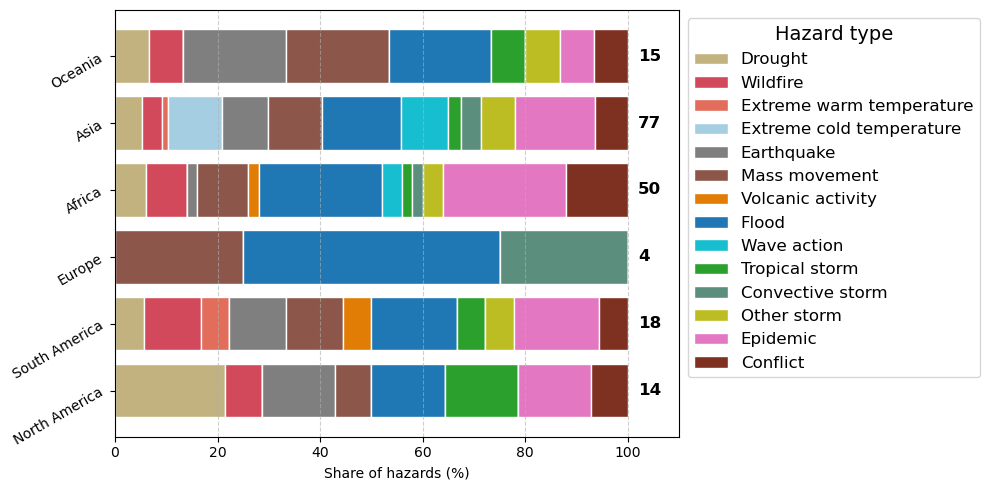

In [102]:
continent_order = ['North America', 'South America', 'Europe', 'Africa', 'Asia',  'Oceania']

# Ensure the columns follow the order of hazard_colormap
# hazard_order = [h for h in hazard_colormap.keys() if h in hazard_counts.columns]
hazard_counts = hazard_counts.loc[continent_order]
hazard_counts = hazard_counts[hazard_order]

# Convert to percentage per continent
hazard_counts_percent = hazard_counts.div(hazard_counts.sum(axis=1), axis=0) * 100
hazard_counts_total = hazard_counts.sum(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

left = [0] * len(hazard_counts)
for hazard in hazard_counts.columns:
    ax.barh(
        hazard_counts.index,
        hazard_counts_percent[hazard],
        left=left,
        color=hazard_colormap.get(hazard, 'gray'),
        edgecolor='white',
        label=hazard
    )
    left += hazard_counts_percent[hazard].values

# Add total counts at end of each bar
for i, total in enumerate(hazard_counts_total):
    ax.text(102, i, f'{total}', va='center', fontsize=12, fontweight='bold')

# Formatting
ax.set_xlim(0, 110)
ax.set_xlabel('Share of hazards (%)')
ax.set_ylabel('')
# ax.set_title('Distribution of Hazard Types by Continent', fontweight='bold')

# Add vertical gridlines from x-axis
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

# Rotate y-axis labels slightly
ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')

# Legend
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Hazard type', title_fontsize=14, fontsize=12)

# Save fig
# fig.savefig(path_save_fig / f"hazard_share_continents.png", 
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"hazard_share_continents.svg", 
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"hazard_share_continents.pdf", 
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_23288\3189098721.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hazard_order, fontsize=fontsize, rotation=20, ha="right")


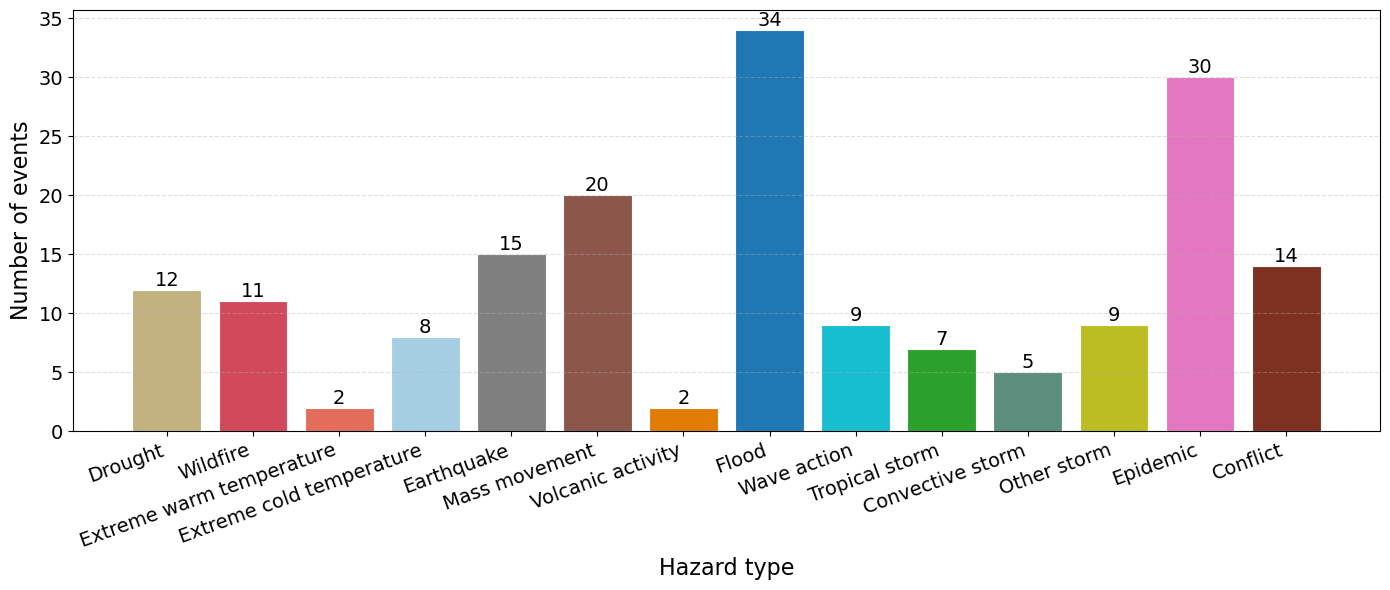

In [103]:
# Bar plot: hazard type vs number of events
hazard_counts = (
    reports_to_label.explode("hazards_found_kw")
    .dropna(subset=["hazards_found_kw"])["hazards_found_kw"]
    .value_counts()
    .rename_axis("hazards_found_kw")
    .reset_index(name="n_events")
)

if "hazard_order" in globals():
    hazard_counts["hazards_found_kw"] = pd.Categorical(
        hazard_counts["hazards_found_kw"],
        categories=hazard_order,
        ordered=True,
    )
    hazard_counts = hazard_counts.sort_values("hazards_found_kw")
else:
    hazard_counts = hazard_counts.sort_values("n_events", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
fontsize=14
bar_colors = [hazard_colormap.get(hazard, "gray") for hazard in hazard_counts["hazards_found_kw"]]
bars = ax.bar(
    hazard_counts["hazards_found_kw"].astype(str),
    hazard_counts["n_events"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
)

ax.set_xlabel("Hazard type", fontsize=fontsize+2)
ax.set_ylabel("Number of events", fontsize=fontsize+2)
# ax.set_title("Number of events by hazard type", fontsize=fontsize+3)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_xticklabels(hazard_order, fontsize=fontsize, rotation=20, ha="right")

for bar, value in zip(bars, hazard_counts["n_events"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=fontsize,
    )

plt.tight_layout()
plt.show()